# imports

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import re
import textwrap
from collections import Counter
from itertools import islice
from pathlib import Path

# functions for e3sm timing log

In [2]:
def _read_numbered_lines(path: Path, first_line: int, last_line: int) -> list[str]:
    with path.open() as handle:
        return [line.rstrip() for line in islice(handle, first_line - 1, last_line)]


def grab_timing(case: str | Path, logid: int) -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    timinglog = sorted(Path(case).glob("timing/e3sm_timing_stats.*"))[logid]
    sypdlog = sorted(Path(case).glob("timing/e3sm_timing.*"))[logid]

    df = pd.read_csv(timinglog, sep=r"\s+", header=4)
    
    s1 = df['name'].str.startswith('a:EAMxx::') 
    s2 = df['name'].str.endswith('::run')
    df2 = df[s1 & s2][1:][['name', 'count', 'walltotal']] 
    processes = [p for p in df2['name'].str.split('::').str[1]]  
    proc_new = [p not in ['EAMxx', 'physics', 'mac_aero_mic'] for p in processes]
    
    df3 = df2[proc_new].sort_values('name')
    processes = [p for p in df3['name'].str.split('::').str[1]]     
  
    compset = 'F2010-EAMxx-MAM4xx'
    if compset == 'F2010-EAMxx-MAM4xx': aer_proc = [p.startswith('mam') for p in processes]
    if compset == 'F2010-SCREAMv1': aer_proc = [p.startswith('spa') for p in processes] 
    
    dfaer = df3[aer_proc].reset_index(drop=True) 
    dfeam = df3[~np.array(aer_proc)] 
    dftmp = pd.DataFrame({'name': 'a:EAMxx::aerosols::run', 'walltotal': dfaer['walltotal'].sum()}, index=[99])
    dfeam = pd.concat([dfeam, dftmp]).reset_index(drop=True) 

    return (
        dfeam,
        dfaer,
        _read_numbered_lines(sypdlog, 34, 40)
    )
    

def plot_process(dfeam, dfaer, axl, axr):
    eam_ratios = dfeam['walltotal'] / dfeam['walltotal'].sum() 
    labels = [p.replace('SurfaceCoupling', 'SC') for p in dfeam['name'].str.split('::').str[1]] 
    labels[labels.index('aerosols')] = 'mam4'
    
    explode = np.zeros(len(labels)) 
    explode[-1] = 0.08
    # rotate so that first wedge is split by the x-axis
    angle = eam_ratios.values[-1] / 2 * 360
    # angle = 0
    perctlimit = 2
    autopct = lambda v: f'{v:.1f}%' if v >= perctlimit else None
    colors = plt.get_cmap('Set3').colors[:]
    wedges, texts, autotexts = axl.pie(eam_ratios, startangle=angle, colors=colors, autopct=autopct, 
                        explode=explode)

    kw = dict(xycoords='data', textcoords='data', arrowprops=dict(arrowstyle="-"), zorder=0, va="center")
    l = []
    for i, p in enumerate(wedges):
        if eam_ratios[i] < perctlimit/100: 
            l.append(f'{labels[i]} ({eam_ratios[i]:.1%})')  
            continue
        else: 
            ang = (p.theta2 - p.theta1)/2. + p.theta1
            y = np.sin(np.deg2rad(ang))
            x = np.cos(np.deg2rad(ang))
            horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
            connectionstyle = "angle,angleA=0,angleB={}".format(ang)
            kw["arrowprops"].update({"connectionstyle": connectionstyle,"color":colors[i]})
            axl.annotate(labels[i], xy=(x, y), xytext=(1.2*np.sign(x), y),
                        horizontalalignment=horizontalalignment, **kw)
    axl.axis('equal') 
    # create handles and labels for legend, take only those where value is < perctlimit
    handles = [h for h,r in zip(wedges,eam_ratios) if r < perctlimit/100]
    axl.legend(handles, l, fontsize='small', ncols=2, bbox_to_anchor=(0.5,-0.02), loc='lower center', 
            title=f'EAMxx process < {perctlimit}%', title_fontsize='small', handlelength=0.5, handleheight=0.5, handletextpad=0.5, columnspacing=0.5)  
    axl.set_title('EAMxx/MAM4xx', fontsize='large', y=0.83)

    mam_ratios = dfaer['walltotal'] / dfaer['walltotal'].sum() 
    mam_labels = ['_'.join(p.split('_')[1:]) for p in dfaer['name'].str.split('::').str[1]]  
    wedges2, *_ = axr.pie(mam_ratios, autopct=autopct, colors=colors) 
    l2 = [] 
    for i, p in enumerate(wedges2):
        if mam_ratios[i] < perctlimit/100: 
            l2.append(f'{mam_labels[i]} ({mam_ratios[i]:.1%})')
            continue
        else: 
            ang = (p.theta2 - p.theta1)/2. + p.theta1
            y = np.sin(np.deg2rad(ang))
            x = np.cos(np.deg2rad(ang))
            horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
            connectionstyle = "angle,angleA=0,angleB={}".format(ang)
            kw["arrowprops"].update({"connectionstyle": connectionstyle,"color":colors[i]})
            axr.annotate(mam_labels[i], xy=(x, y), xytext=(1.15*np.sign(x), y),
                        horizontalalignment=horizontalalignment, **kw)
    handles = [h for h,r in zip(wedges2,mam_ratios) if r < perctlimit/100]
    axr.legend(handles, l2, fontsize='small', ncols=2, bbox_to_anchor=(0.5,-0.02), loc='lower center', 
            title=f'MAM4xx process < {perctlimit}%', title_fontsize='small', handlelength=0.5, handleheight=0.5, handletextpad=0.5, columnspacing=0.5)  
    axr.set_title('MAM4xx', fontsize='large', y=0.83)
    axr.axis('equal')

# Computational cost of EAMxx and MAMxx processes (from e3sm timing)

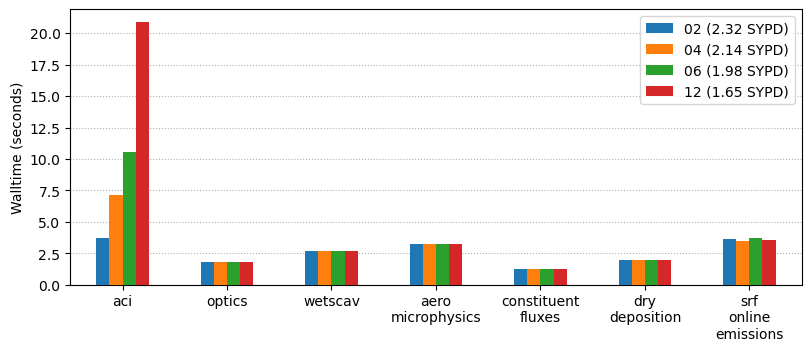

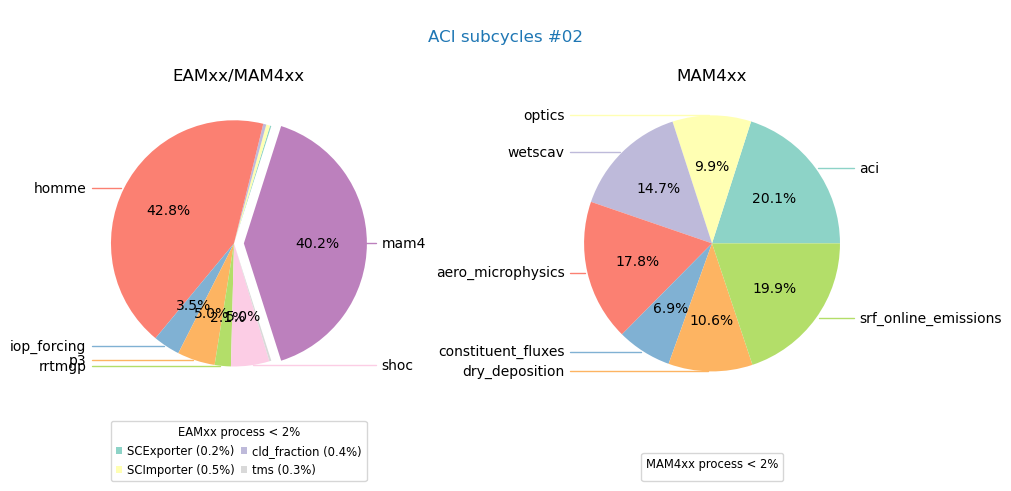

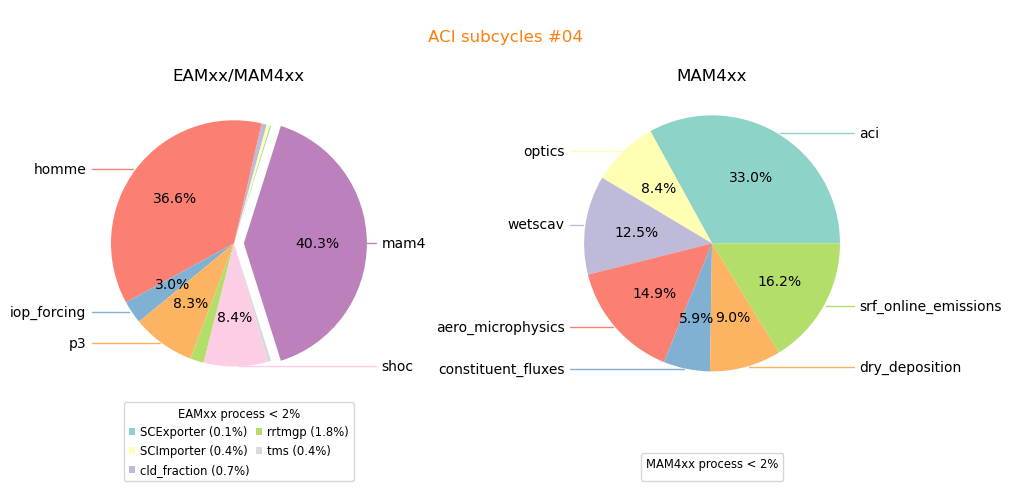

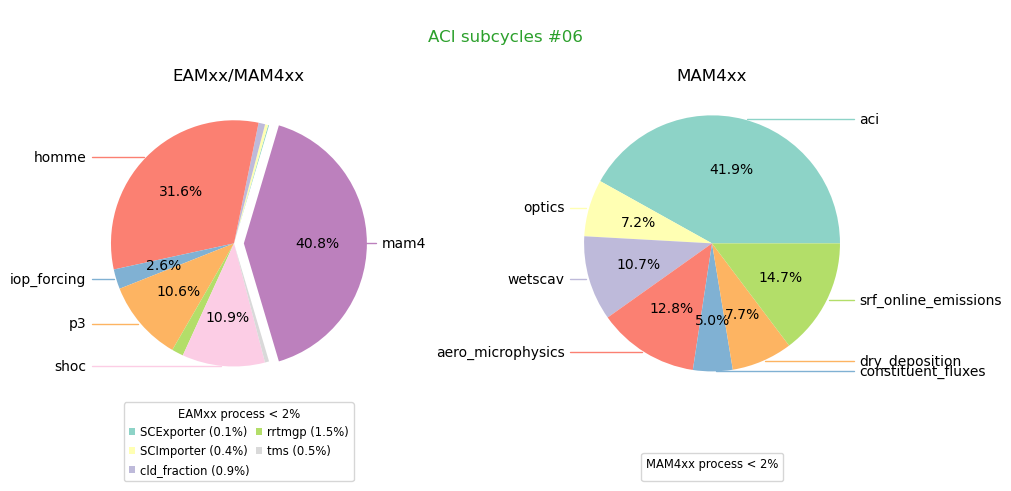

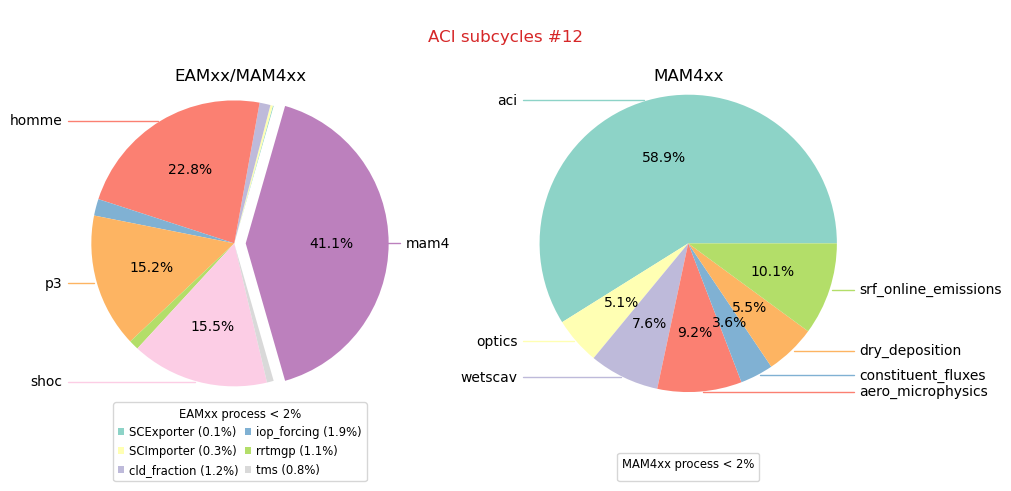

In [3]:
indir = '/pscratch/sd/m/meng/dp_screamxx/mamxx/scream_dpxx_DYCOMSrf01'

# Mapping case names to log IDs, in sorted order within the E3SM timing directory. 
cases = {
    '02': 3,
    '04': 2,
    '06': 1,
    '12': 0,
}

team, taer, sypd = {}, {}, {}
for cn, logid in cases.items():
    team[cn], taer[cn], sypd[cn] = grab_timing(indir, logid)

# bar plot for MAM processes
df_combined = {}
for cn in cases.keys():
    out = taer[cn]['walltotal'].values 
    pdp = [p for p in taer[cn]['name'].str.split('::').str[1]]

    casename = cn + f" ({sypd[cn][1].split()[2]} SYPD)"
    df_combined[casename] = out 

df_combined = pd.DataFrame(df_combined)
df_combined['name'] = pdp

fig, ax = plt.subplots(figsize=(8, 3.4), constrained_layout=True)
df_combined.set_index('name').plot.bar(ax=ax, zorder=99)
ax.set_xticklabels([f'{("\n").join(p.split("_")[1:])}' for p in pdp], rotation=0)
ax.set_ylabel('Walltime (seconds)')
ax.set_xlabel('')
ax.grid(axis='y', ls=':')

# compare EAMxx and MAMxx shares of total time
i = 0 
for cn in cases.keys():
    fig, axs = plt.subplots(figsize=(10, 4.8), ncols=2, constrained_layout=True)
    fig.suptitle('ACI subcycles #' + cn, fontsize='large', y=0.95, color=f'C{str(i)}')
    plot_process(team[cn], taer[cn], axs[0], axs[1])
    i += 1 

# functions for Kokkos kernel timer

In [4]:
def _clean_callable_name(name: str) -> str:
    match = re.match(
        r"^scream::_GLOBAL__N__[^:]*?_eamxx_mam_([a-z0-9_]+)_process_interface_cpp_[^:]*::([A-Za-z_]\w*)$",
        name,
    )
    if match:
        process, function = match.groups()
        return f"{process}::{function}"
    return name


def readable_kernel_name(name: str, max_length: int = 70) -> str:
    """Reduce template-heavy CUDA/Kokkos labels to meaningful callables."""
    name = " ".join(str(name).split())

    callable_match = re.search(
        r"__nv_dl_tag<.*?,\s*&?((?:[A-Za-z_]\w*::)+[A-Za-z_]\w*)\s*,\s*\d+>",
        name,
    )
    if callable_match:
        return f"{_clean_callable_name(callable_match.group(1))} [CUDA/Kokkos]"

    callable_targets = re.findall(r"&((?:[A-Za-z_]\w*::)+[A-Za-z_]\w*)", name)
    if callable_targets:
        return f"{_clean_callable_name(callable_targets[-1])} [CUDA/Kokkos]"

    if len(name) <= max_length:
        return name

    application_names = [
        item for item in re.findall(r"\b(?:[A-Za-z_]\w*::)+[A-Za-z_]\w*\b", name)
        if not item.startswith(
            ("Kokkos::", "KokkosKernels::", "FunctorAnalysis::", "FunctorPatternInterface::")
        )
    ]
    if application_names:
        return f"CUDA/Kokkos wrapper: {_clean_callable_name(application_names[0])}"

    if "CombinedFunctorReducer" in name:
        return "Kokkos reduction (template signature)"
    if "__nv_hdl_wrapper_t" in name:
        return "CUDA/Kokkos wrapper (truncated signature)"

    return textwrap.shorten(name, width=max_length, placeholder=" …")


def make_unique(labels: list[str]) -> list[str]:
    """Disambiguate parsed labels only when two labels collide."""
    totals = Counter(labels)
    seen: Counter[str] = Counter()
    unique_labels: list[str] = []

    for label in labels:
        if totals[label] == 1:
            unique_labels.append(label)
            continue
        seen[label] += 1
        unique_labels.append(f"{label} (variant {seen[label]})")

    return unique_labels


def read_kernels(csv_path: str | Path) -> pd.DataFrame:
    """Read, validate, and return the top kernels ranked by mean time."""
    df = pd.read_csv(Path(csv_path))
    rank_time_columns = ["mean_rank_seconds", "min_rank_seconds", "max_rank_seconds"]
    required_columns = ["kernel_name", "kernel_type", *rank_time_columns]
    df[rank_time_columns] = df[rank_time_columns].apply(pd.to_numeric, errors="coerce")
    return df.dropna(subset=required_columns)
    

def plot_kernels(
    df: pd.DataFrame,
    ax: plt.Axes,
    title: str,
    *,
    barcolor: str = 'C0',
    label_width: int = 35,
    xlim: tuple[float, float] | None = None,
) -> plt.Axes:
    parsed_names = make_unique(
        [readable_kernel_name(name) for name in df["kernel_name"]]
    )
    labels = [
        textwrap.fill(
            f"[{kind}] {name.replace('run_impl::', '')}",
            width=label_width,
            break_long_words=False,
            break_on_hyphens=False,
        )
        for kind, name in zip(df["kernel_type"], parsed_names)
    ]

    means = df["mean_rank_seconds"].to_numpy(dtype=float)
    minima = df["min_rank_seconds"].to_numpy(dtype=float)
    maxima = df["max_rank_seconds"].to_numpy(dtype=float)
    asymmetric_errors = np.vstack((np.maximum(means - minima, 0), np.maximum(maxima - means, 0)))
    y_positions = np.arange(len(df))

    ax.barh(
        y_positions,
        means,
        xerr=asymmetric_errors,
        height=0.62,
        color=barcolor,
        edgecolor="none",
        error_kw={
            "ecolor": "#17202A",
            "elinewidth": 1.7,
            "capsize": 5,
            "capthick": 1.7,
        },
    )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel("Rank time (seconds)")
    ax.set_ylabel("")
    ax.set_title(
        title,
        pad=14,
    )

    largest_max = float(maxima.max())
    x_max = xlim[1] if xlim is not None else (largest_max * 1.30 if largest_max > 0 else 1.0)
    annotation_gap = x_max * 0.015 if x_max > 0 else 0.01
    for y, mean, minimum, maximum in zip(
        y_positions, means, minima, maxima
    ):
        ax.text(
            maximum + annotation_gap,
            y,
            f"{mean:.3f} s  [{minimum:.3f}, {maximum:.3f}]",
            va="center",
            ha="left",
            fontsize=9,
        )

    # Leave room for error bars and their exact-value annotations.
    ax.set_xlim(*(xlim if xlim is not None else (0, x_max)))
    ax.grid(axis="x", linestyle="--", linewidth=0.8, alpha=0.35)
    ax.set_axisbelow(True)
    for spine_name in ("top", "right", "left"):
        ax.spines[spine_name].set_visible(False)
    ax.tick_params(axis="y", length=0)
    return ax 

# kokkos_tools timing

In [5]:
# create csv file
%run ./parse_kernel_timer.py 

Parsing /pscratch/sd/m/meng/dp_screamxx/mamxx/scream_dpxx_DYCOMSrf01/run_02/e3sm.log.56336663.260804-145818.gz for case: run_02 ...
Parsed 10192 timing records
Found reports from 4 rank executions
Created kernel_timer_by_rank_02.csv
Created kernel_timer_aggregated_02.csv
Parsing /pscratch/sd/m/meng/dp_screamxx/mamxx/scream_dpxx_DYCOMSrf01/run_04/e3sm.log.56336324.260804-144743.gz for case: run_04 ...
Parsed 10192 timing records
Found reports from 4 rank executions
Created kernel_timer_by_rank_04.csv
Created kernel_timer_aggregated_04.csv
Parsing /pscratch/sd/m/meng/dp_screamxx/mamxx/scream_dpxx_DYCOMSrf01/run_06/e3sm.log.56332246.260804-125634.gz for case: run_06 ...
Parsed 10192 timing records
Found reports from 4 rank executions
Created kernel_timer_by_rank_06.csv
Created kernel_timer_aggregated_06.csv
Parsing /pscratch/sd/m/meng/dp_screamxx/mamxx/scream_dpxx_DYCOMSrf01/run_12/e3sm.log.56331328.260804-120136.gz for case: run_12 ...
Parsed 10192 timing records
Found reports from 4 ran

In [6]:
# generate one-page plot for top kernels across ACI subcycles
csvdir = Path('/pscratch/sd/m/meng/kokkos_tools')
subcycles = ['02', '04', '06', '12']
top_n = 10


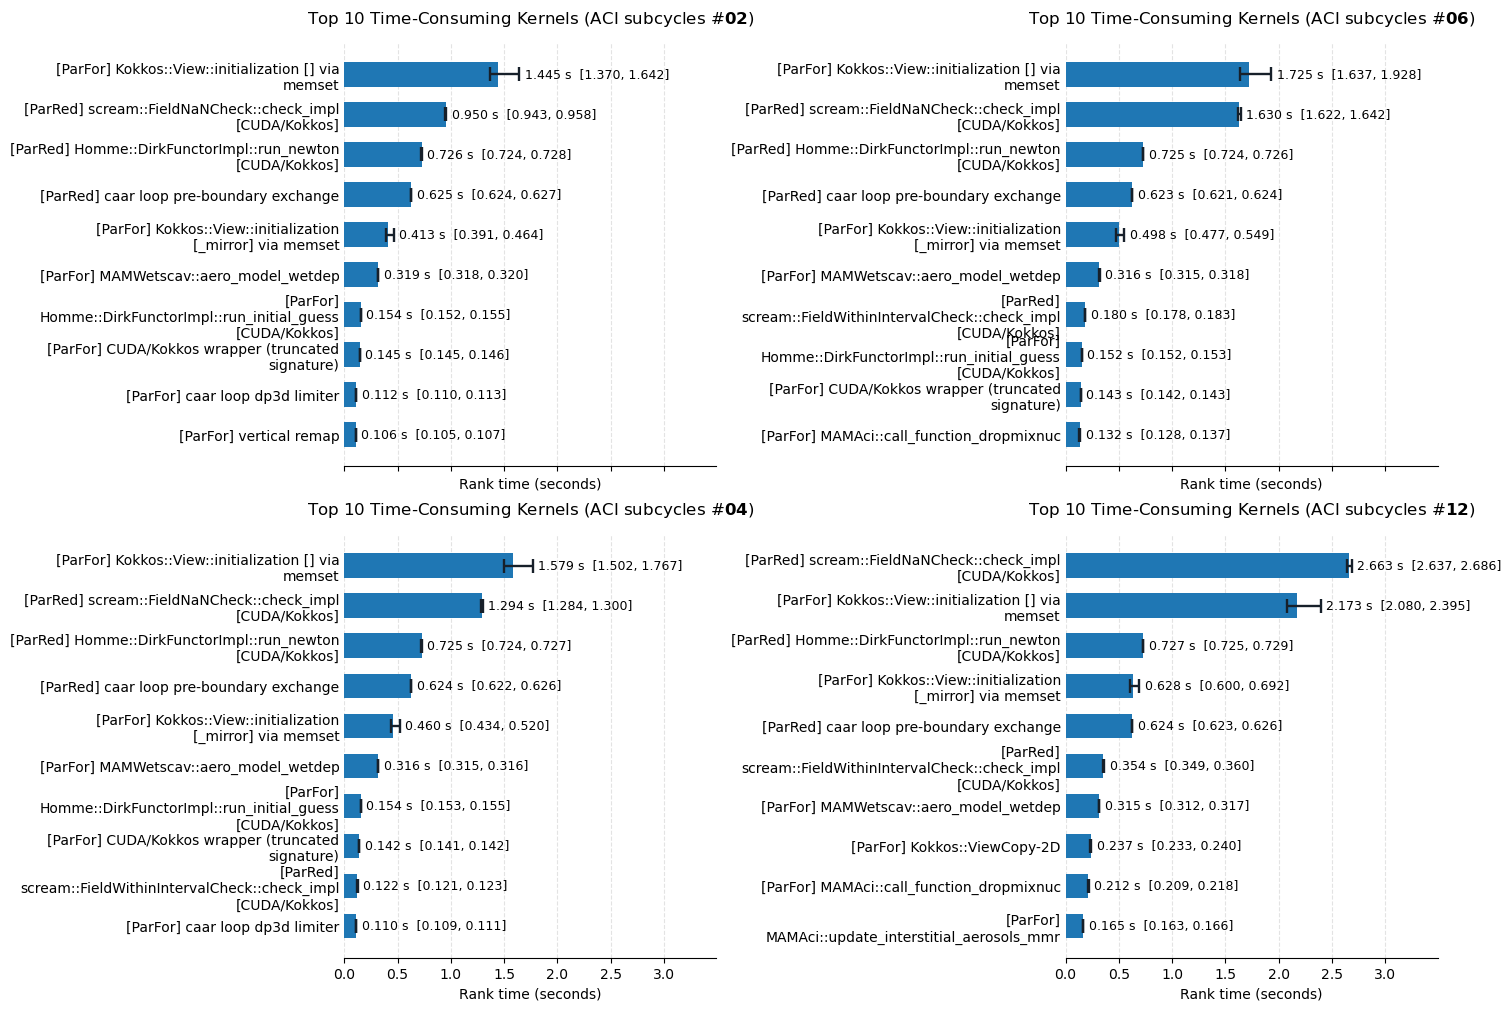

In [7]:

top_by_subcycle = {
    subcycle: read_kernels(csvdir / f'kernel_timer_aggregated_{subcycle}.csv').nlargest(
        top_n, "mean_rank_seconds"
    )
    for subcycle in subcycles
}
shared_xmax = max(float(top['max_rank_seconds'].max()) for top in top_by_subcycle.values())
shared_xlim = (0, shared_xmax * 1.30 if shared_xmax > 0 else 1.0)

fig, axs = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True, sharex=True)
for ax, subcycle in zip(axs.T.flat, subcycles):
    ax = plot_kernels(
        top_by_subcycle[subcycle],
        ax=ax,
        xlim=shared_xlim,
        label_width=46,
        title=rf'Top {top_n} Time-Consuming Kernels (ACI subcycles #$\mathbf{{{subcycle}}}$)',
    )

## mamaci kernels

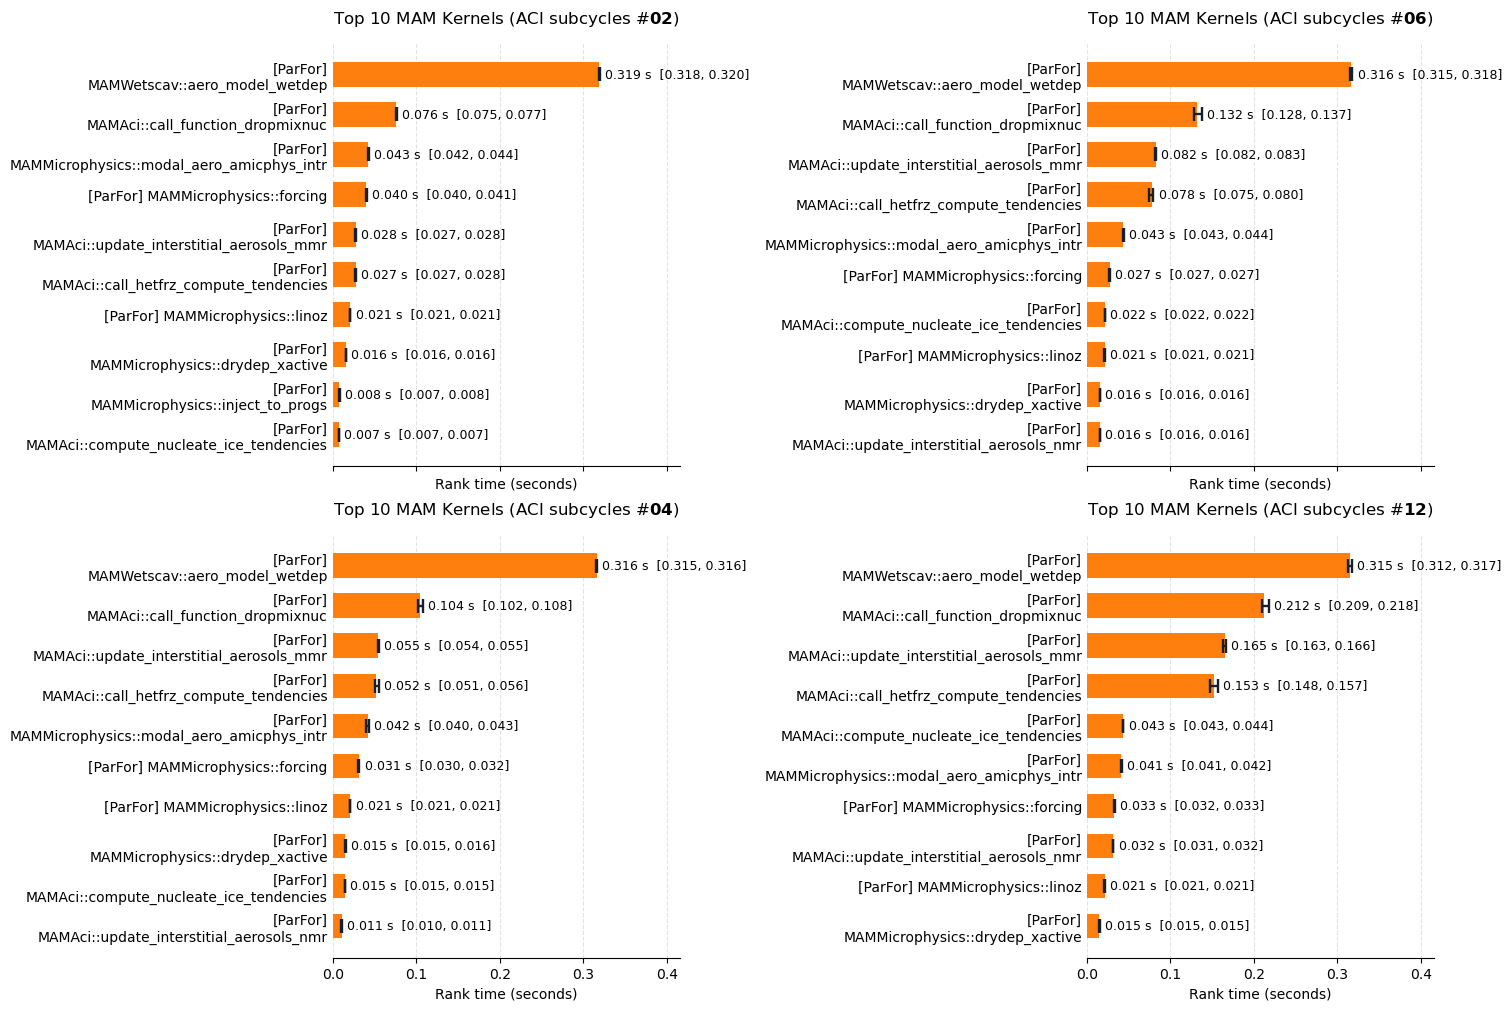

In [8]:
subcycles = ['02', '04', '06', '12']
mam_by_subcycle = {}
top_n = 10
for subcycle in subcycles:
    df_kernels = read_kernels(csvdir / f'kernel_timer_aggregated_{subcycle}.csv')
    mam_by_subcycle[subcycle] = df_kernels[df_kernels['kernel_name'].str.startswith('MAM')].iloc[:top_n]

shared_xmax = max(float(top['max_rank_seconds'].max()) for top in mam_by_subcycle.values())
shared_xlim = (0, shared_xmax * 1.30 if shared_xmax > 0 else 1.0)

fig, axs = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True, sharex=True)
for ax, subcycle in zip(axs.T.flat, subcycles):
    plot_kernels(
        mam_by_subcycle[subcycle],
        ax=ax,
        xlim=shared_xlim,
        title=rf'Top {top_n} MAM Kernels (ACI subcycles #$\mathbf{{{subcycle}}}$)',
        barcolor='C1',
    )

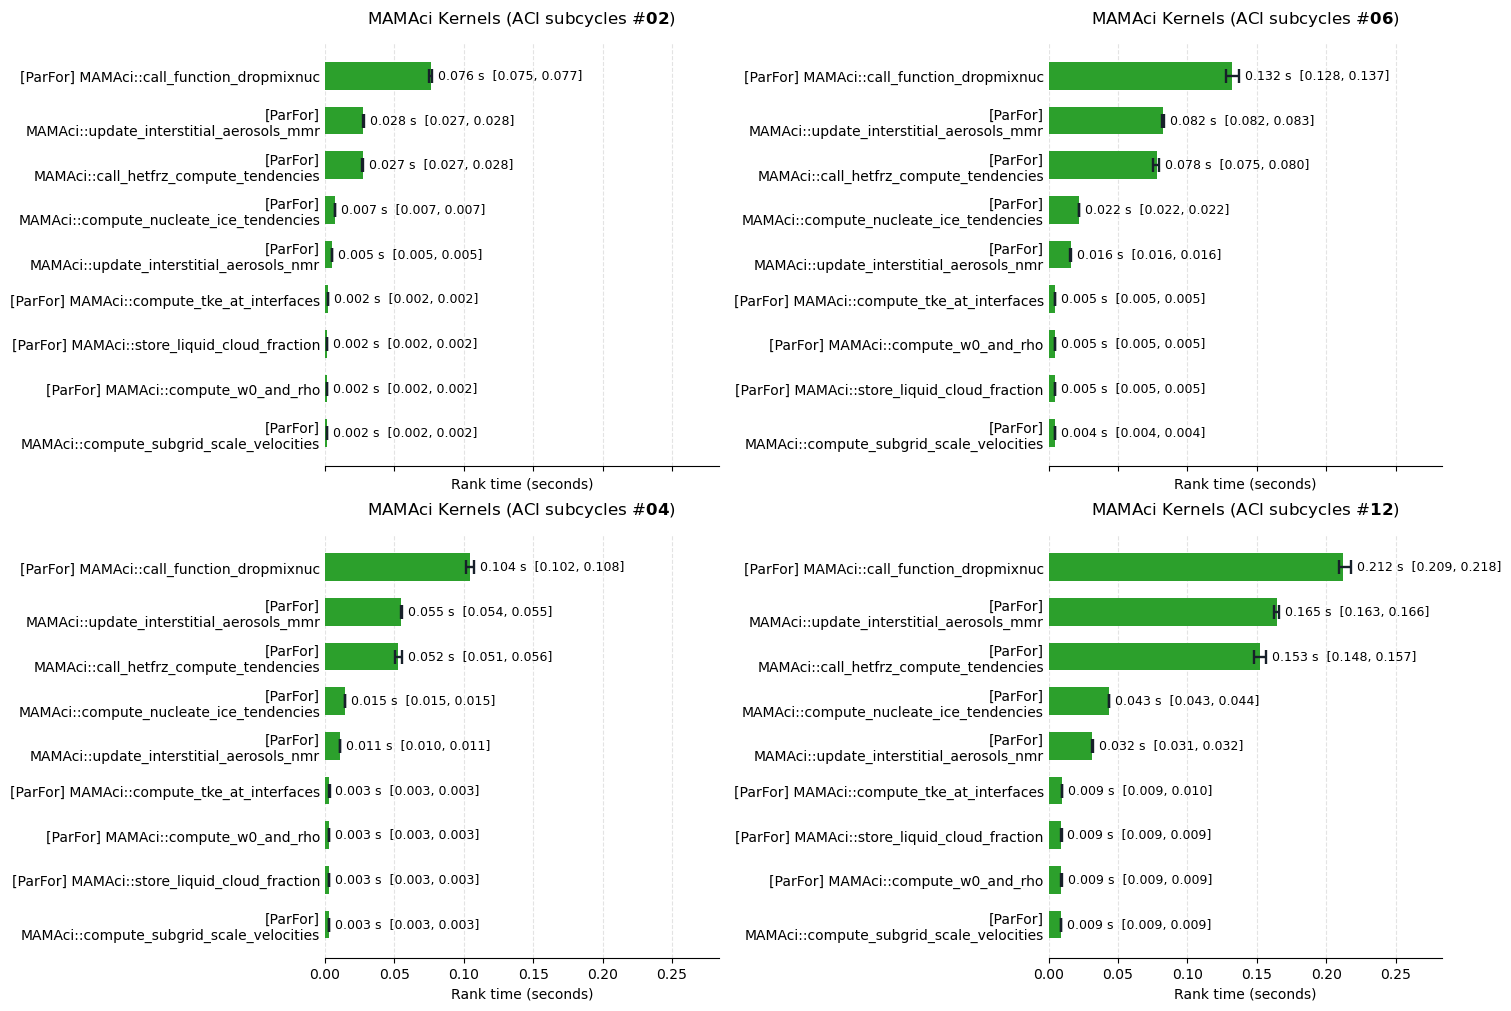

In [9]:
subcycles = ['02', '04', '06', '12']
mamaci_by_subcycle = {}
for subcycle in subcycles:
    df_kernels = read_kernels(csvdir / f'kernel_timer_aggregated_{subcycle}.csv')
    mamaci_by_subcycle[subcycle] = df_kernels[df_kernels['kernel_name'].str.startswith('MAMAci')].iloc[:10]

shared_xmax = max(float(top['max_rank_seconds'].max()) for top in mamaci_by_subcycle.values())
shared_xlim = (0, shared_xmax * 1.30 if shared_xmax > 0 else 1.0)

fig, axs = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True, sharex=True)
for ax, subcycle in zip(axs.T.flat, subcycles):
    plot_kernels(
        mamaci_by_subcycle[subcycle],
        ax=ax,
        xlim=shared_xlim,
        label_width=46,
        title=rf'MAMAci Kernels (ACI subcycles #$\mathbf{{{subcycle}}}$)',
        barcolor='C2',
    )